# Validation des R-C-Modells 
Validation der Python addaption des R-C-Modells. Als grundlage gelten das Modell geschreiben in Matlab und die ergebnisse der IDA ICE Simulation von Lorenzzo Zgraggen.





In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.io import loadmat
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 1.5

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from core.bootstrap import create_facade



In [2]:
# Define project and variant IDs
PROJECT_ID = "rc-model-validation"
VARIANT_ID = "Val"

# Run simulation and load all data
facade_Val = create_facade(PROJECT_ID, VARIANT_ID)
facade_Val.run_simulation(PROJECT_ID, VARIANT_ID)
df_res_py = facade_Val._result.load_raw().drop(columns=["temperature_outdoor_air"], axis=1)

# Load MATLAB reference
mat_path = Path(PROJECT_ROOT) / 'projects' / 'rc-model-validation' / 'mat-reference' / 'matlab_ref_results.mat'
mat_data = loadmat(mat_path, squeeze_me=True)
df_res_mat = pd.DataFrame({
    'output_heating_power': mat_data['output_heating_power'],
    'output_cooling_power': mat_data['output_cooling_power'],
    'output_lighting_electricity': mat_data['output_lighting_electricity'],
    'output_equipment_electricity': mat_data['output_equipment_electricity']
})
temp_mat_array = mat_data['output_temperatures']
row_names_all = df_res_py.columns.tolist()
row_names = row_names_all[:-4]
df_temp_outputs = pd.DataFrame(data=temp_mat_array, columns=row_names)
df_res_mat = pd.concat([df_temp_outputs, df_res_mat], axis=1)
df_res_mat.index = df_res_py.index

# Load IDA ICE reference
ida_path = Path(PROJECT_ROOT) / 'projects' / 'rc-model-validation' / 'mat-reference' / 'ida_results_ver2.mat'
ida_data = loadmat(ida_path, squeeze_me=True)
df_res_ida = pd.DataFrame({
    "temperature_air_room": ida_data['ida_air_temp'],
    "output_heating_power": ida_data['ida_heating_power'],
    "output_cooling_power": -ida_data['ida_cooling_power'],
})
df_res_ida.index = df_res_py.index

# print result lengths
print(f"Python results: {len(df_res_py)} hours")
print(f"MATLAB reference: {len(df_res_mat)} hours")
print(f"IDA ICE reference: {len(df_res_ida)} hours")

KeyError: 'enable_cooling'

# 1. Jahresenergie Vergleich


$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1} \left(y_{i}- \hat y_{i} \right)²}
$$

$y_i$ ist der Wert vom Modell geschrieben in Python. $\hat y_i$ ist der Wert aus dem Modell geschreiben in MATLAB, welcher als referenz dient. 

$$
E_{m,x}
= \sum_{i=1}^{n} \dot{Q}_{m,x,i} \cdot \Delta t
$$

$$
\Delta E_{m_1,m_2,x}
= E_{m_1,x} - E_{m_2,x}
$$

$$
\delta E_{m_1,m_2,x}
= \left( \frac{E_{m_1,x}}{E_{m_2,x}} - 1 \right) \cdot 100
$$

$$
\overline{T}_m
= \frac{1}{n} \sum_{i=1}^{n} T_{m,i}
$$

$$
T_{m,\min} = \min(T_{m,i})
\qquad
T_{m,\max} = \max(T_{m,i})
$$

$$
\sigma_{T,m}
= \sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left( T_{m,i} - \overline{T}_m \right)^2
}
$$

$$
\Delta T_{m_1,m_2,i}
= T_{m_1,i} - T_{m_2,i}
$$

$$
\mathrm{ME}_{m_1,m_2}
= \frac{1}{n}
\sum_{i=1}^{n}
\Delta T_{m_1,m_2,i}
$$

$$
\mathrm{RMSE}_{m_1,m_2}
= \sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left( \Delta T_{m_1,m_2,i} \right)^2
}
$$

$$
\mathrm{MAE}_{\max,m_1,m_2}
= \max \left( \left| \Delta T_{m_1,m_2,i} \right| \right)
$$

In [ ]:
# Calculate energy totals
py_heat = df_res_py['output_heating_power'].sum()/1e6
py_cool = df_res_py['output_cooling_power'].sum()/1e6
py_light = df_res_py['output_lighting_electricity'].sum()/1e6
py_equip = df_res_py['output_equipment_electricity'].sum()/1e6

ml_heat = df_res_mat['output_heating_power'].sum()/1e6
ml_cool = df_res_mat['output_cooling_power'].sum()/1e6
ml_light = df_res_mat['output_lighting_electricity'].sum()/1e6
ml_equip = df_res_mat['output_equipment_electricity'].sum()/1e6

ida_heat = df_res_ida['output_heating_power'].sum()/1e6
ida_cool = df_res_ida['output_cooling_power'].sum()/1e6

# Create summary table
summary = pd.DataFrame({
    'Python': [py_heat, py_cool, py_light, py_equip],
    'MATLAB': [ml_heat, ml_cool, ml_light, ml_equip],
    'IDA ICE': [ida_heat, ida_cool, np.nan, np.nan]
}, index=['Heizen (MWh)', 'Kühlen (MWh)', 'Beleuchtung (MWh)', 'Geräte (MWh)'])

summary['Python-MATLAB Δ'] = summary['Python'] - summary['MATLAB']
summary['Python-MATLAB %'] = ((summary['Python'] / summary['MATLAB']) - 1) * 100
summary['Python-IDA Δ'] = summary['Python'] - summary['IDA ICE']
summary['Python-IDA %'] = ((summary['Python'] / summary['IDA ICE']) - 1) * 100

print("\nTabelle 1: Vergleich Jahresenergie (MWh)\n")
print(summary.round(2).to_string())

# Temperature statistics
temp_py = df_res_py['temperature_air_room'].values
temp_ml = df_res_mat['temperature_air_room'].values
temp_ida = df_res_ida['temperature_air_room'].values

temp_diff_ml = temp_py - temp_ml    # Temperature difference between Python and MATLAB. Python minus MATLAB.
temp_diff_ida = temp_py - temp_ida  # Temperature difference between Python and IDA ICE. Python minus IDA ICE.

print(f"\n\nTabelle 2: Innenraumtemperatur-Statistiken (°C)\n")
temp_stats = pd.DataFrame({
    'Python': [temp_py.mean(), temp_py.min(), temp_py.max(), temp_py.std()],
    'MATLAB': [temp_ml.mean(), temp_ml.min(), temp_ml.max(), temp_ml.std()],
    'IDA ICE': [temp_ida.mean(), temp_ida.min(), temp_ida.max(), temp_ida.std()]
}, index=['Mittelwert', 'Min', 'Max', 'Standardabweichung'])
print(temp_stats.round(2).to_string())

print(f"\n\nTabelle 3: Temperaturvalidierungskennzahlen (°C)\n")
metrics = pd.DataFrame({
    'Python vs MATLAB': [
        temp_diff_ml.mean(),
        np.sqrt(np.mean(temp_diff_ml**2)),
        np.max(np.abs(temp_diff_ml))
    ],
    'Python vs IDA': [
        temp_diff_ida.mean(),
        np.sqrt(np.mean(temp_diff_ida**2)),
        np.max(np.abs(temp_diff_ida))
    ],
    'MATLAB vs IDA': [
        (temp_ml - temp_ida).mean(),
        np.sqrt(np.mean((temp_ml - temp_ida)**2)),
        np.max(np.abs(temp_ml - temp_ida))
    ]
}, index=['Mean Error', 'RMSE', 'Max Absolute Error'])
print(metrics.round(4).to_string())



Tabelle 1: Vergleich Jahresenergie (MWh)

                   Python  MATLAB  IDA ICE  Python-MATLAB Δ  Python-MATLAB %  Python-IDA Δ  Python-IDA %
Heizen (MWh)        56.61   53.93    60.02             2.68             4.97         -3.41         -5.68
Kühlen (MWh)        -0.55   -0.28    -0.19            -0.27            96.96         -0.35        181.39
Beleuchtung (MWh)    3.59    3.40      NaN             0.18             5.40           NaN           NaN
Geräte (MWh)        16.77   16.77      NaN             0.00             0.00           NaN           NaN


Tabelle 2: Innenraumtemperatur-Statistiken (°C)

                    Python  MATLAB  IDA ICE
Mittelwert           22.06   22.06    21.85
Min                  20.88   20.88    20.94
Max                  26.05   26.04    26.04
Standardabweichung    1.58    1.57     1.34


Tabelle 3: Temperaturvalidierungskennzahlen (°C)

                    Python vs MATLAB  Python vs IDA  MATLAB vs IDA
Mean Error                   -0.0020      

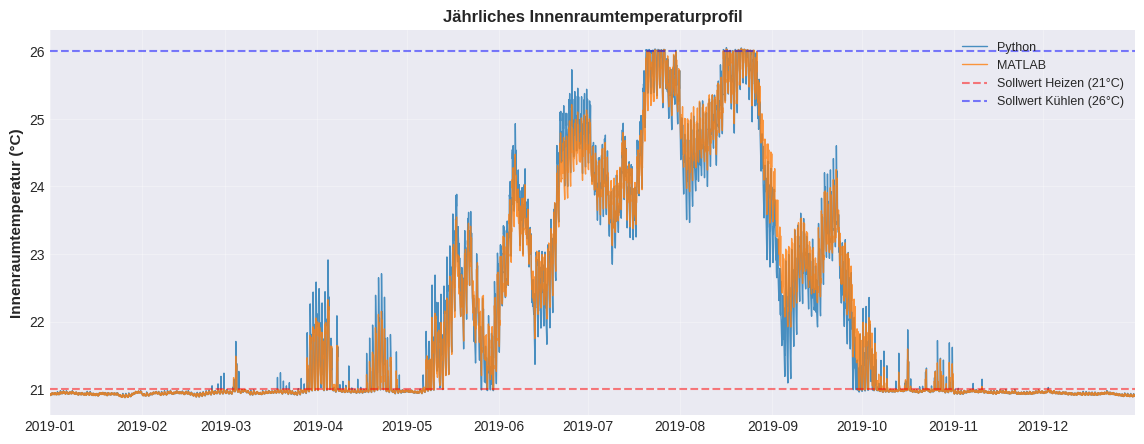

In [ ]:
idx = df_res_py.index
# Plot: Temperature over full year
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
ax.plot(idx, temp_py, label='Python', color='#1f77b4', linewidth=1, alpha=0.8)
ax.plot(idx, temp_ml, label='MATLAB', color='#ff7f0e', linewidth=1, alpha=0.8)
ax.axhline(21, color='red', linestyle='--', alpha=0.5, label='Sollwert Heizen (21°C)')
ax.axhline(26, color='blue', linestyle='--', alpha=0.5, label='Sollwert Kühlen (26°C)')
ax.set_ylabel('Innenraumtemperatur (°C)', fontsize=11, fontweight='bold')
ax.set_title('Jährliches Innenraumtemperaturprofil', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(idx[0], idx[-1])

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'temperature_profile.png', dpi=300, bbox_inches='tight')

In [ ]:
summary

,Python,MATLAB,IDA ICE,Python-MATLAB Δ,Python-MATLAB %,Python-IDA Δ,Python-IDA %
Heizen (MWh),56.613628,53.932796,60.023979,2.680833e+00,4.970691e+00,-3.410351,-5.681647
Kühlen (MWh),-0.546302,-0.277374,-0.194144,-2.689280e-01,9.695503e+01,-0.352158,181.390515
Beleuchtung (MWh),3.585750,3.401997,NaN,1.837536e-01,5.401344e+00,NaN,NaN
Geräte (MWh),16.768217,16.768217,NaN,3.552714e-15,2.220446e-14,NaN,NaN


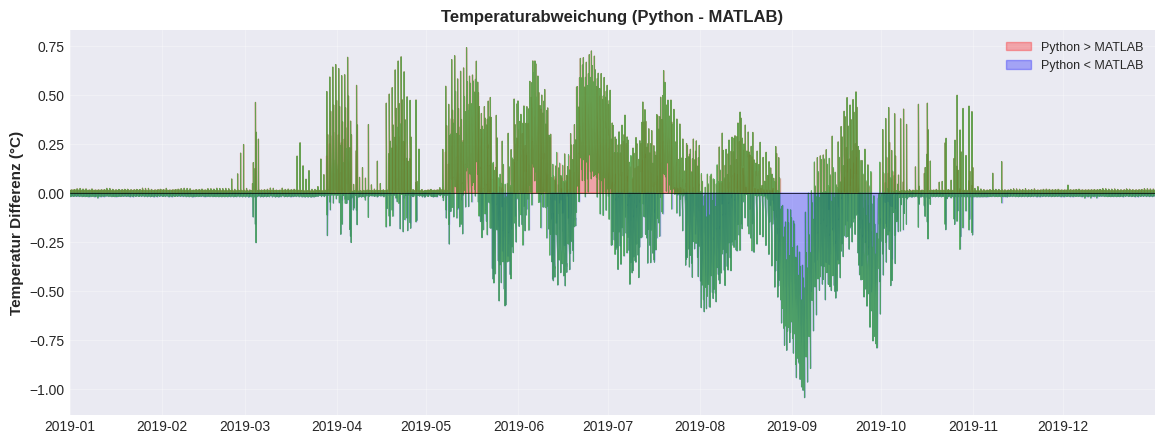

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
ax.plot(idx, temp_diff_ml, color='#2ca02c', linewidth=0.8, alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.fill_between(idx, 0, temp_diff_ml, where=(temp_diff_ml>=0), alpha=0.3, color='red', label='Python > MATLAB')
ax.fill_between(idx, 0, temp_diff_ml, where=(temp_diff_ml<0), alpha=0.3, color='blue', label='Python < MATLAB')
ax.set_ylabel('Temperatur Differenz (°C)', fontsize=11, fontweight='bold')
ax.set_title('Temperaturabweichung (Python - MATLAB)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(idx[0], idx[-1])

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'temperature_difference.png', dpi=300, bbox_inches='tight')

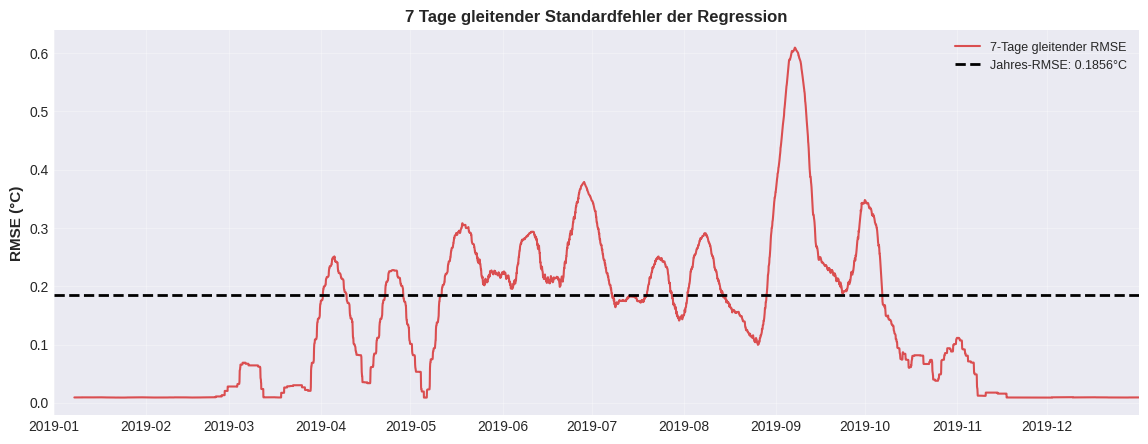

In [ ]:
# Plot: temperature difference
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
rolling_rmse = pd.Series(temp_diff_ml, index=idx).rolling(window=168).apply(lambda x: np.sqrt(np.mean(x**2)))
ax.plot(idx, rolling_rmse, color='#d62728', linewidth=1.5, alpha=0.8, label='7-Tage gleitender RMSE')
ax.axhline(np.sqrt(np.mean(temp_diff_ml**2)), color='black', linestyle='--', linewidth=2, label=f'Jahres-RMSE: {np.sqrt(np.mean(temp_diff_ml**2)):.4f}°C')
ax.set_ylabel('RMSE (°C)', fontsize=11, fontweight='bold')
ax.set_title('7 Tage gleitender Standardfehler der Regression', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(idx[0], idx[-1])

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'temperature_rmse.png', dpi=300, bbox_inches='tight')

In [ ]:
heating_py = df_res_py['output_heating_power'].values
heating_ml = df_res_mat['output_heating_power'].values
cooling_py = df_res_py['output_cooling_power'].values
cooling_ml = df_res_mat['output_cooling_power'].values


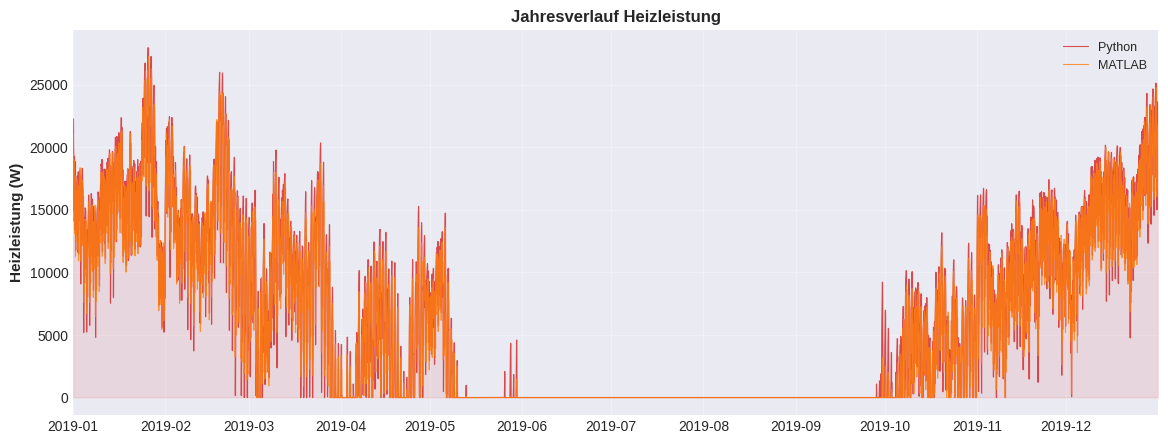

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))

# Plot 1: Heating power over year
ax = axes
ax.plot(idx, heating_py, label='Python', color='#d62728', linewidth=0.8, alpha=0.8)
ax.plot(idx, heating_ml, label='MATLAB', color='#ff7f0e', linewidth=0.8, alpha=0.8)
ax.fill_between(idx, 0, heating_py, alpha=0.1, color='#d62728')
ax.set_ylabel('Heizleistung (W)', fontsize=11, fontweight='bold')
ax.set_title('Jahresverlauf Heizleistung', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(idx[0], idx[-1])

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'heating_power_over_year.png', dpi=300, bbox_inches='tight')

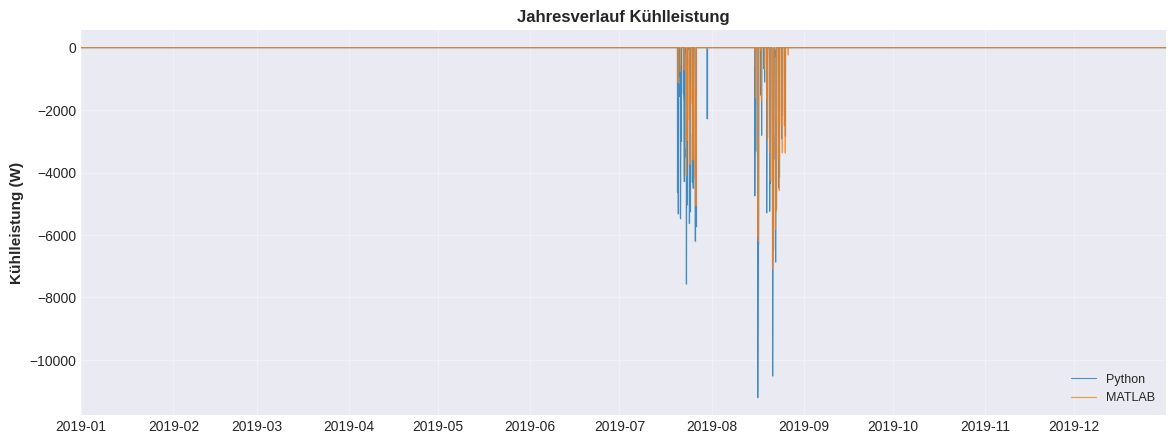

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
# Plot 2: Cooling power over year
ax = axes
ax.plot(idx, cooling_py, label='Python', color='#1f77b4', linewidth=0.8, alpha=0.8)
ax.plot(idx, cooling_ml, label='MATLAB', color='#ff7f0e', linewidth=0.8, alpha=0.8)
ax.fill_between(idx, 0, cooling_py, alpha=0.1, color='#1f77b4')
ax.set_ylabel('Kühlleistung (W)', fontsize=11, fontweight='bold')
ax.set_title('Jahresverlauf Kühlleistung', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(idx[0], idx[-1])

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'cooling_power_over_year.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_6206/805122165.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  py_monthly_heat = pd.Series(heating_py, index=idx).resample('M').sum()/1e6
/tmp/ipykernel_6206/805122165.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ml_monthly_heat = pd.Series(heating_ml, index=idx).resample('M').sum()/1e6


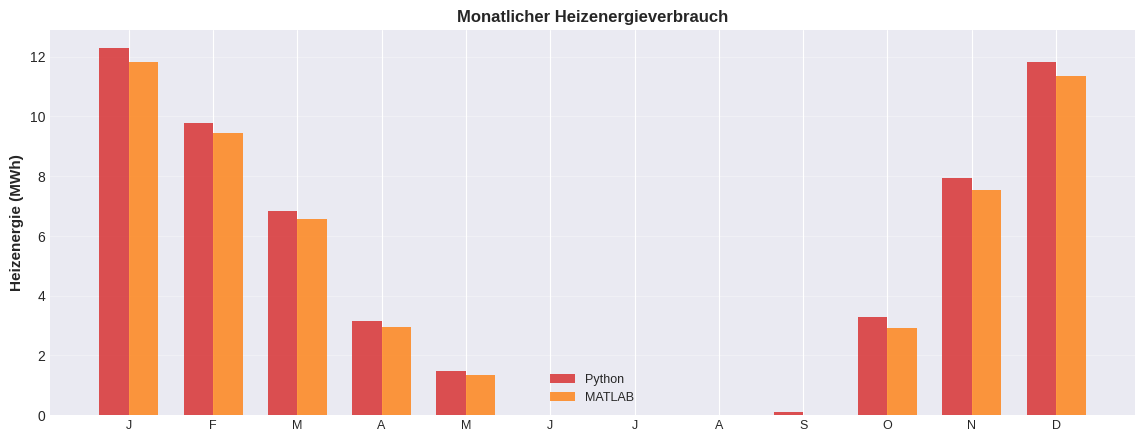

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
# Plot 3: Monthly heating comparison
ax = axes
py_monthly_heat = pd.Series(heating_py, index=idx).resample('M').sum()/1e6
ml_monthly_heat = pd.Series(heating_ml, index=idx).resample('M').sum()/1e6
x_pos = np.arange(len(py_monthly_heat))
width = 0.35
ax.bar(x_pos - width/2, py_monthly_heat.values, width, label='Python', color='#d62728', alpha=0.8)
ax.bar(x_pos + width/2, ml_monthly_heat.values, width, label='MATLAB', color='#ff7f0e', alpha=0.8)
ax.set_ylabel('Heizenergie (MWh)', fontsize=11, fontweight='bold')
ax.set_title('Monatlicher Heizenergieverbrauch', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'], fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'monthly_heating_comparison.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_6206/1535856929.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  py_monthly_cool = pd.Series(cooling_py, index=idx).resample('M').sum()/1e6
/tmp/ipykernel_6206/1535856929.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ml_monthly_cool = pd.Series(cooling_ml, index=idx).resample('M').sum()/1e6


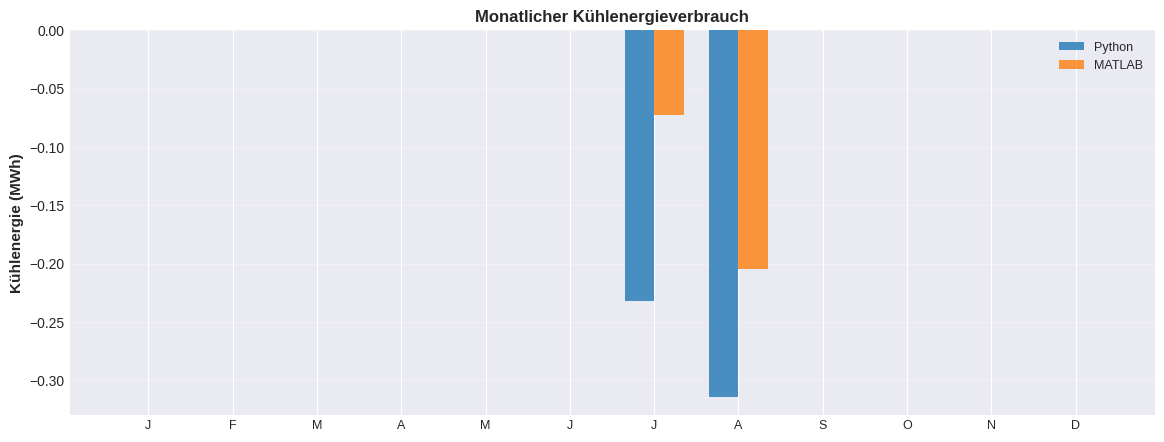

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))

ax = axes
py_monthly_cool = pd.Series(cooling_py, index=idx).resample('M').sum()/1e6
ml_monthly_cool = pd.Series(cooling_ml, index=idx).resample('M').sum()/1e6
ax.bar(x_pos - width/2, py_monthly_cool.values, width, label='Python', color='#1f77b4', alpha=0.8)
ax.bar(x_pos + width/2, ml_monthly_cool.values, width, label='MATLAB', color='#ff7f0e', alpha=0.8)
ax.set_ylabel('Kühlenergie (MWh)', fontsize=11, fontweight='bold')
ax.set_title('Monatlicher Kühlenergieverbrauch', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'], fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'monthly_cooling_comparison.png', dpi=300, bbox_inches='tight')


# Error distribution

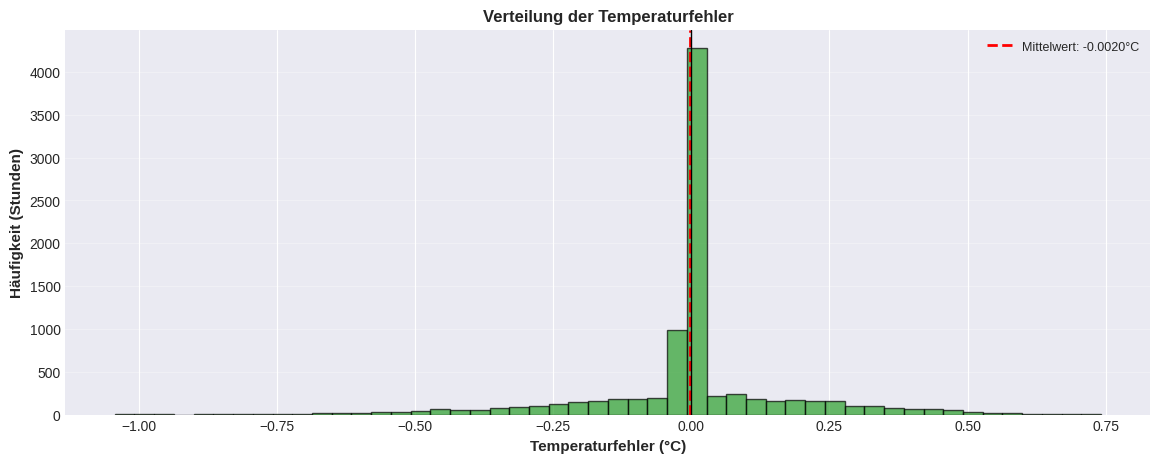

In [ ]:
# plot temperature error distribution
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
ax.hist(temp_diff_ml, bins=50, color='#2ca02c', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(temp_diff_ml), color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {np.mean(temp_diff_ml):.4f}°C')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Temperaturfehler (°C)', fontsize=11, fontweight='bold')
ax.set_ylabel('Häufigkeit (Stunden)', fontsize=11, fontweight='bold')
ax.set_title('Verteilung der Temperaturfehler', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'temperature_error_distribution.png', dpi=300, bbox_inches='tight')

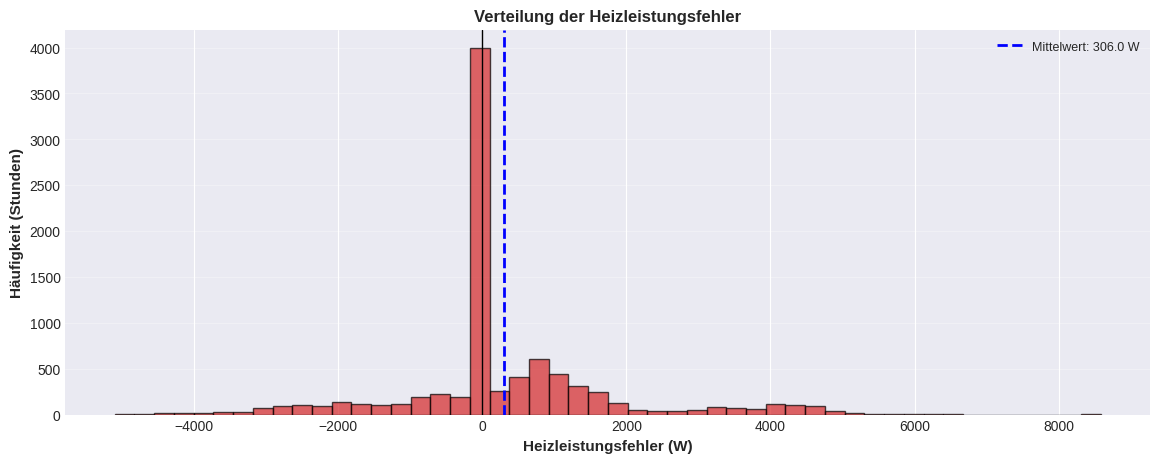

In [ ]:
# Calculate hourly energy differences
heating_diff = heating_py - heating_ml
cooling_diff = cooling_py - cooling_ml

# plot temperature error distribution
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
ax.hist(heating_diff, bins=50, color='#d62728', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(heating_diff), color='blue', linestyle='--', linewidth=2, label=f'Mittelwert: {np.mean(heating_diff):.1f} W')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Heizleistungsfehler (W)', fontsize=11, fontweight='bold')
ax.set_ylabel('Häufigkeit (Stunden)', fontsize=11, fontweight='bold')
ax.set_title('Verteilung der Heizleistungsfehler', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'heating_power_error_distribution.png', dpi=300, bbox_inches='tight')

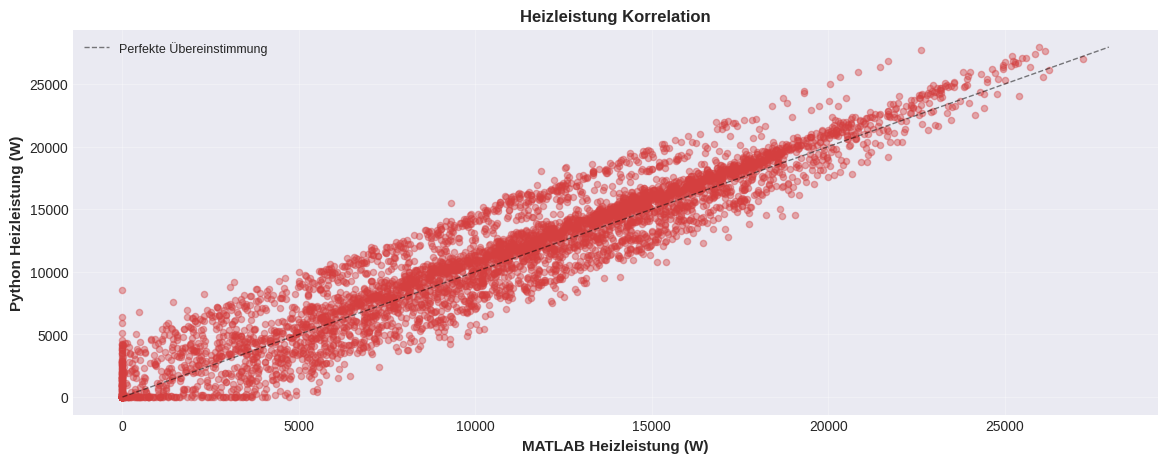

In [ ]:
# plot heating power correlation
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
sample_idx = np.arange(0, len(heating_py), 1)
ax.scatter(heating_ml[sample_idx], heating_py[sample_idx], alpha=0.4, s=20, color="#d43f3f")
max_val = max(heating_ml.max(), heating_py.max())
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Perfekte Übereinstimmung')
ax.set_xlabel('MATLAB Heizleistung (W)', fontsize=11, fontweight='bold')
ax.set_ylabel('Python Heizleistung (W)', fontsize=11, fontweight='bold')
ax.set_title('Heizleistung Korrelation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'heating_power_correlation.png', dpi=300, bbox_inches='tight')

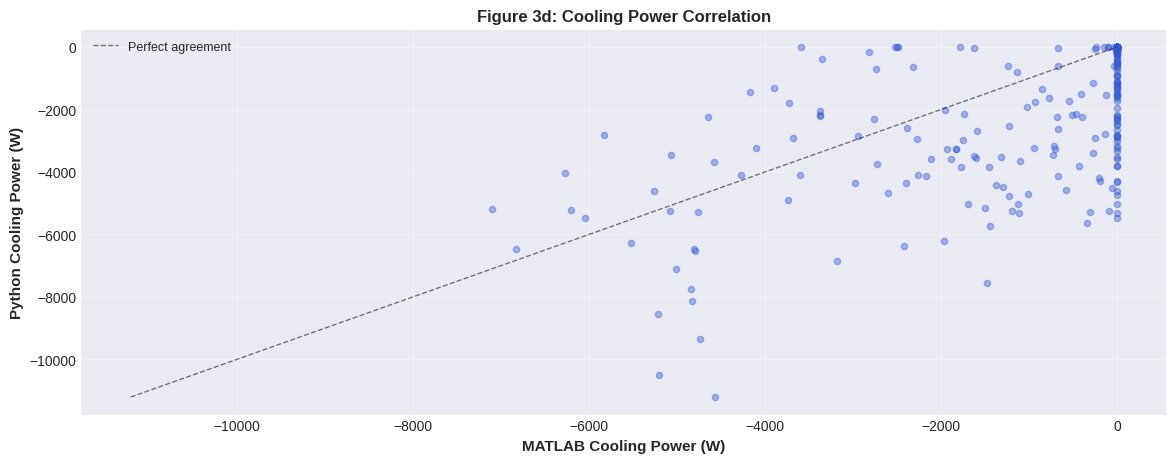

In [ ]:
# plot cooling power correlation
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(14, 5))
ax = axes
ax.scatter(cooling_ml[sample_idx], cooling_py[sample_idx], alpha=0.4, s=20, color="#3457d5")
# ax.scatter(cooling_ml, cooling_py, alpha=0.4, s=20, color="#299d8e")
min_val = min(cooling_ml.min(), cooling_py.min())
max_val = max(cooling_ml.max(), cooling_py.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, alpha=0.5, label='Perfect agreement')
ax.set_xlabel('MATLAB Cooling Power (W)', fontsize=11, fontweight='bold')
ax.set_ylabel('Python Cooling Power (W)', fontsize=11, fontweight='bold')
ax.set_title('Figure 3d: Cooling Power Correlation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.savefig(Path(PROJECT_ROOT) / 'notebooks' / 'figures' /'cooling_power_correlation.png', dpi=300, bbox_inches='tight')

In [ ]:
# Generate Latex Tables for reports 

# anual energy table
latex_table_ann_energy = summary.to_latex(
    caption='Vergleich des Jahresenergiebedarfs (MWh)', # Deutsche Beschriftung
    label='tab:jahresenergie', # Eindeutiges Label zum Verweisen
    float_format="%.2f", # Auf zwei Dezimalstellen formatieren
    index=True, # Setzen Sie dies auf True, wenn die Zeilenbeschriftungen (Heating, Cooling etc.) der Index sind
    position='htbp'
)

# temperature statistics table
latex_table_temp_stats = temp_stats.to_latex(
    caption='Statistiken der Innenraumtemperatur (°C)',
    label='tab:tempstats',
    float_format="%.2f",
    index=True,
    position='htbp'
)

# temperature metrics table
latex_table_temp_metrics = metrics.to_latex(
    caption='Validierungskennzahlen der Innenraumtemperatur (°C)',
    label='tab:tempmetrics',
    float_format="%.4f",
    index=True,
    position='htbp'
)

print("Latex Tables for Reports:\n")
print("Anual Energy Table:\n")
print(latex_table_ann_energy)
print("-" * 100)
print("Temperature Statistics Table:\n")
print(latex_table_temp_stats)
print("-" * 100)
print("Temperature Metrics Table:\n")
print(latex_table_temp_metrics)

Latex Tables for Reports:

Anual Energy Table:

\begin{table}[htbp]
\caption{Vergleich des Jahresenergiebedarfs (MWh)}
\label{tab:jahresenergie}
\begin{tabular}{lrrrrrrr}
\toprule
 & Python & MATLAB & IDA ICE & Python-MATLAB Δ & Python-MATLAB % & Python-IDA Δ & Python-IDA % \\
\midrule
Heizen (MWh) & 56.61 & 53.93 & 60.02 & 2.68 & 4.97 & -3.41 & -5.68 \\
Kühlen (MWh) & -0.55 & -0.28 & -0.19 & -0.27 & 96.96 & -0.35 & 181.39 \\
Beleuchtung (MWh) & 3.59 & 3.40 & NaN & 0.18 & 5.40 & NaN & NaN \\
Geräte (MWh) & 16.77 & 16.77 & NaN & 0.00 & 0.00 & NaN & NaN \\
\bottomrule
\end{tabular}
\end{table}

----------------------------------------------------------------------------------------------------
Temperature Statistics Table:

\begin{table}[htbp]
\caption{Statistiken der Innenraumtemperatur (°C)}
\label{tab:tempstats}
\begin{tabular}{lrrr}
\toprule
 & Python & MATLAB & IDA ICE \\
\midrule
Mittelwert & 22.06 & 22.06 & 21.85 \\
Min & 20.88 & 20.88 & 20.94 \\
Max & 26.05 & 26.04 & 26.04 \\
Sta

In [ ]:
# Validate
df_diff = df_res_py.subtract(df_res_mat, fill_value=0)
df_diff_ida = df_res_py[df_res_ida.columns].subtract(df_res_ida, fill_value=0)

print("\n" + "="*90)
print("VALIDATION: Python vs. MATLAB vs. IDA ICE")
print("="*90)

# Temperature
temp_diff = df_diff["temperature_air_room"]
temp_max = np.max(np.abs(temp_diff))
temp_rmse = np.sqrt(np.mean(temp_diff**2))
print(f"\nTEMPERATURE (°C)")
print(f"  Max Error:  {temp_max:>8.4f}°C  |  RMSE: {temp_rmse:>8.4f}°C  |  Mean: {np.mean(temp_diff):>+8.4f}°C")

# Heating
heat_diff = df_diff["output_heating_power"]
py_heat = df_res_py['output_heating_power'].sum()/1e6
ml_heat = df_res_mat['output_heating_power'].sum()/1e6
heat_pct = ((py_heat/ml_heat-1)*100) if ml_heat != 0 else 0
print(f"\nHEATING (MWh)")
print(f"  Python: {py_heat:>8.2f}  |  MATLAB: {ml_heat:>8.2f}  |  Diff: {py_heat-ml_heat:>+8.2f} ({heat_pct:>+6.1f}%)")

# Cooling
cool_diff = df_diff["output_cooling_power"]
py_cool = df_res_py['output_cooling_power'].sum()/1e6
ml_cool = df_res_mat['output_cooling_power'].sum()/1e6
print(f"\nCOOLING (MWh)")
print(f"  Python: {py_cool:>8.2f}  |  MATLAB: {ml_cool:>8.2f}  |  Diff: {py_cool-ml_cool:>+8.2f}")

# IDA comparison
temp_diff_ida = df_diff_ida["temperature_air_room"]
temp_rmse_ida = np.sqrt(np.mean(temp_diff_ida**2))
print(f"\nPython vs. IDA ICE")
print(f"  Temp RMSE: {temp_rmse_ida:>8.4f}°C")

# Summary
print("\n" + "="*90)
if temp_max < 0.5 and abs(heat_pct) < 1.0:
    print("✓✓✓ VALIDATION SUCCESSFUL")
elif temp_max < 1.0 and abs(heat_pct) < 5.0:
    print("✓ VALIDATION ACCEPTABLE")
else:
    print("⚠ Discrepancies remain - further investigation needed")
print("="*90)


VALIDATION: Python vs. MATLAB vs. IDA ICE

TEMPERATURE (°C)
  Max Error:    1.0432°C  |  RMSE:   0.1856°C  |  Mean:  -0.0020°C

HEATING (MWh)
  Python:    56.61  |  MATLAB:    53.93  |  Diff:    +2.68 (  +5.0%)

COOLING (MWh)
  Python:    -0.55  |  MATLAB:    -0.28  |  Diff:    -0.27

Python vs. IDA ICE
  Temp RMSE:   0.4306°C

⚠ Discrepancies remain - further investigation needed


In [ ]:
# Diagnostics: energy totals and first-winter-week diff
# Totals (MWh)
energies = {
    "py_heating_MWh": df_res_py['output_heating_power'].sum()/1e6,
    "py_cooling_MWh": df_res_py['output_cooling_power'].sum()/1e6,
    "py_lighting_MWh": df_res_py['output_lighting_electricity'].sum()/1e6,
    "py_equipment_MWh": df_res_py['output_equipment_electricity'].sum()/1e6,
    "mat_heating_MWh": df_res_mat['output_heating_power'].sum()/1e6,
    "mat_cooling_MWh": df_res_mat['output_cooling_power'].sum()/1e6,
    "mat_lighting_MWh": df_res_mat['output_lighting_electricity'].sum()/1e6,
    "mat_equipment_MWh": df_res_mat['output_equipment_electricity'].sum()/1e6,
}
print("\nENERGY TOTALS (MWh)")
for k,v in energies.items():
    print(f"  {k:20s}: {v:8.3f}")

# First winter week (hours 0-167)
wk = slice(0, 168)
print("\nFIRST WINTER WEEK (hours 0-167):")
print(f"  Heating diff sum (MWh): {(df_diff['output_heating_power'].iloc[wk].sum()/1e6):+.3f}")
print(f"  Cooling diff sum (MWh): {(df_diff['output_cooling_power'].iloc[wk].sum()/1e6):+.3f}")
print(f"  Temp RMSE (°C): {np.sqrt(np.mean(df_diff['temperature_air_room'].iloc[wk]**2)):.4f}")



ENERGY TOTALS (MWh)
  py_heating_MWh      :   56.614
  py_cooling_MWh      :   -0.546
  py_lighting_MWh     :    3.586
  py_equipment_MWh    :   16.768
  mat_heating_MWh     :   53.933
  mat_cooling_MWh     :   -0.277
  mat_lighting_MWh    :    3.402
  mat_equipment_MWh   :   16.768

FIRST WINTER WEEK (hours 0-167):
  Heating diff sum (MWh): +0.089
  Cooling diff sum (MWh): +0.000
  Temp RMSE (°C): 0.0092


In [ ]:
# Diagnostics: monthly breakdown and selected weeks
# build a datetime index for grouping
idx = pd.date_range("2020-01-01", periods=len(df_res_py), freq="H")
py = df_res_py.copy(); py.index = idx
mat = df_res_mat.copy(); mat.index = idx

monthly = pd.DataFrame({
    "py_heat_MWh": py['output_heating_power'].resample('M').sum()/1e6,
    "ml_heat_MWh": mat['output_heating_power'].resample('M').sum()/1e6,
    "py_cool_MWh": py['output_cooling_power'].resample('M').sum()/1e6,
    "ml_cool_MWh": mat['output_cooling_power'].resample('M').sum()/1e6,
    "py_temp_mean": py['temperature_air_room'].resample('M').mean(),
    "ml_temp_mean": mat['temperature_air_room'].resample('M').mean(),
})
monthly['heat_diff'] = monthly['py_heat_MWh'] - monthly['ml_heat_MWh']
monthly['cool_diff'] = monthly['py_cool_MWh'] - monthly['ml_cool_MWh']

print("\nMONTHLY HEAT/COOL (MWh)")
print(monthly[['py_heat_MWh','ml_heat_MWh','heat_diff','py_cool_MWh','ml_cool_MWh','cool_diff']].round(2))

# Winter week (Jan 1-7) and summer week (Jul 1-7)
winter = slice("2020-01-01","2020-01-07 23:00")
summer = slice("2020-07-01","2020-07-07 23:00")

for label, sl in [("WINTER_WEEK", winter), ("SUMMER_WEEK", summer)]:
    h_diff = df_diff.loc[:, 'output_heating_power']
    c_diff = df_diff.loc[:, 'output_cooling_power']
    t_diff = df_diff.loc[:, 'temperature_air_room']
    h_sum = h_diff[sl].sum()/1e6
    c_sum = c_diff[sl].sum()/1e6
    t_rmse = np.sqrt(np.mean(t_diff[sl]**2))
    print(f"\n{label}:")
    print(f"  Heating diff (MWh): {h_sum:+.3f}")
    print(f"  Cooling diff (MWh): {c_sum:+.3f}")
    print(f"  Temp RMSE (°C):    {t_rmse:.4f}")



MONTHLY HEAT/COOL (MWh)
            py_heat_MWh  ml_heat_MWh  heat_diff  py_cool_MWh  ml_cool_MWh  \
2020-01-31        12.27        11.83       0.45         0.00         0.00   
2020-02-29        10.02         9.67       0.35         0.00         0.00   
2020-03-31         6.62         6.34       0.28         0.00         0.00   
2020-04-30         3.31         3.09       0.22         0.00         0.00   
2020-05-31         1.29         1.19       0.09         0.00         0.00   
2020-06-30         0.00         0.00       0.00         0.00         0.00   
2020-07-31         0.00         0.00       0.00        -0.23        -0.07   
2020-08-31         0.00         0.00       0.00        -0.31        -0.20   
2020-09-30         0.14         0.03       0.11         0.00         0.00   
2020-10-31         3.48         3.13       0.35         0.00         0.00   
2020-11-30         7.95         7.56       0.39         0.00         0.00   
2020-12-31        11.53        11.09       0.44    

/tmp/ipykernel_6206/1869460458.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range("2020-01-01", periods=len(df_res_py), freq="H")
/tmp/ipykernel_6206/1869460458.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "py_heat_MWh": py['output_heating_power'].resample('M').sum()/1e6,
/tmp/ipykernel_6206/1869460458.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "ml_heat_MWh": mat['output_heating_power'].resample('M').sum()/1e6,
/tmp/ipykernel_6206/1869460458.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "py_cool_MWh": py['output_cooling_power'].resample('M').sum()/1e6,
/tmp/ipykernel_6206/1869460458.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "ml_cool_MWh": mat['output_cooling_powe

In [ ]:
# Diagnostics: net load deltas (heating deficit + extra cooling)
net_gain_diff_MWh = -(df_diff['output_heating_power'].sum()/1e6 + df_diff['output_cooling_power'].sum()/1e6)
net_gain_diff_Wavg = net_gain_diff_MWh * 1e6 / (len(df_res_py) * 3600)
print(f"\nNET GAIN DIFFERENCE (Python vs MATLAB)")
print(f"  Total surplus gains: {net_gain_diff_MWh:+.3f} MWh")
print(f"  Average surplus power: {net_gain_diff_Wavg:+.1f} W")

# Monthly net
df_month = df_diff[['output_heating_power','output_cooling_power']].copy()
df_month.index = pd.date_range("2020-01-01", periods=len(df_month), freq="H")
month_net = -(df_month.resample('M').sum().sum(axis=1))/1e6
print("\nMONTHLY NET GAIN DIFFERENCE (MWh):")
print(month_net.round(3))



NET GAIN DIFFERENCE (Python vs MATLAB)
  Total surplus gains: -2.412 MWh
  Average surplus power: -0.1 W

MONTHLY NET GAIN DIFFERENCE (MWh):
2020-01-31   -0.448
2020-02-29   -0.351
2020-03-31   -0.276
2020-04-30   -0.218
2020-05-31   -0.094
2020-06-30   -0.000
2020-07-31    0.160
2020-08-31    0.109
2020-09-30   -0.112
2020-10-31   -0.348
2020-11-30   -0.391
2020-12-31   -0.441
Freq: ME, dtype: float64


/tmp/ipykernel_6206/140772442.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_month.index = pd.date_range("2020-01-01", periods=len(df_month), freq="H")
/tmp/ipykernel_6206/140772442.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_net = -(df_month.resample('M').sum().sum(axis=1))/1e6
